In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns

In [2]:
df = pd.read_csv('training.1600000.processed.noemoticon.csv', encoding='latin-1', header=None)
df = df[[0, 5]]
df.columns = ['polarity', 'text']
print(df.head())

   polarity                                               text
0         0  @switchfoot http://twitpic.com/2y1zl - Awww, t...
1         0  is upset that he can't update his Facebook by ...
2         0  @Kenichan I dived many times for the ball. Man...
3         0    my whole body feels itchy and like its on fire 
4         0  @nationwideclass no, it's not behaving at all....


In [3]:
df = df[df.polarity != 2]

df['polarity'] = df['polarity'].map({0: 0, 4: 1})

print(df['polarity'].value_counts())

polarity
0    800000
1    800000
Name: count, dtype: int64


In [4]:
def clean_text(text):
    return text.lower()
df['clean_text'] = df['text'].apply(clean_text)
print(df[['text', 'clean_text']].head())

                                                text  \
0  @switchfoot http://twitpic.com/2y1zl - Awww, t...   
1  is upset that he can't update his Facebook by ...   
2  @Kenichan I dived many times for the ball. Man...   
3    my whole body feels itchy and like its on fire    
4  @nationwideclass no, it's not behaving at all....   

                                          clean_text  
0  @switchfoot http://twitpic.com/2y1zl - awww, t...  
1  is upset that he can't update his facebook by ...  
2  @kenichan i dived many times for the ball. man...  
3    my whole body feels itchy and like its on fire   
4  @nationwideclass no, it's not behaving at all....  


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'],
    df['polarity'],
    test_size=0.4,
    random_state=42
)
print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 960000
Test size: 640000


In [6]:
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF shape (train):", X_train_tfidf.shape)
print("TF-IDF shape (test):", X_test_tfidf.shape)

TF-IDF shape (train): (960000, 5000)
TF-IDF shape (test): (640000, 5000)


In [8]:
logreg = LogisticRegression(max_iter=100)
logreg.fit(X_train_tfidf, y_train)

logreg_pred = logreg.predict(X_test_tfidf)

print("Logistic Regression Accuracy:", accuracy_score(y_test, logreg_pred))
print("\nLogistic Regression Classification Report:\n", classification_report(y_test, logreg_pred))

Logistic Regression Accuracy: 0.79606875

Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.78      0.79    319729
           1       0.79      0.81      0.80    320271

    accuracy                           0.80    640000
   macro avg       0.80      0.80      0.80    640000
weighted avg       0.80      0.80      0.80    640000



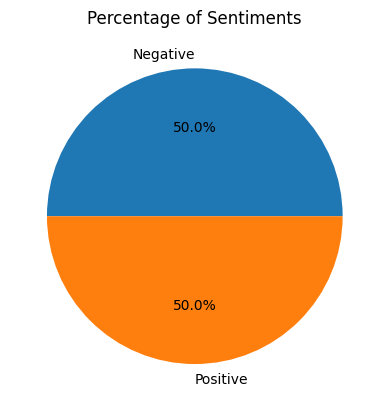

In [10]:
sentiment_counts = df['polarity'].value_counts()
plt.pie(sentiment_counts,
        labels=['Negative','Positive'],
        autopct='%1.1f%%')
plt.title("Percentage of Sentiments")
plt.show()

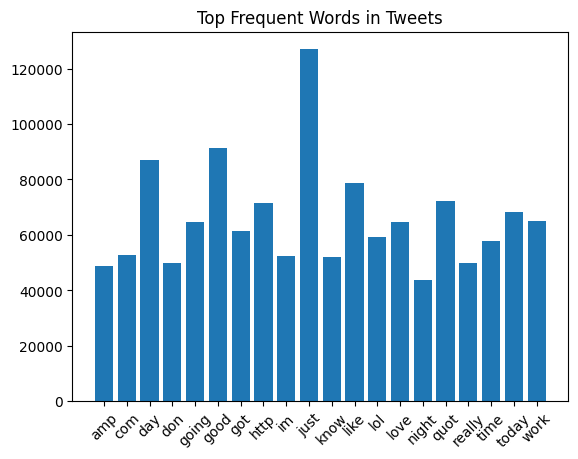

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words='english', max_features=20)

X = vectorizer.fit_transform(df['clean_text'])

words = vectorizer.get_feature_names_out()

counts = X.toarray().sum(axis=0)

plt.bar(words, counts)

plt.title("Top Frequent Words in Tweets")
plt.xticks(rotation=45)

plt.show()

In [12]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, logreg_pred)

print(cm)

[[250699  69030]
 [ 61486 258785]]


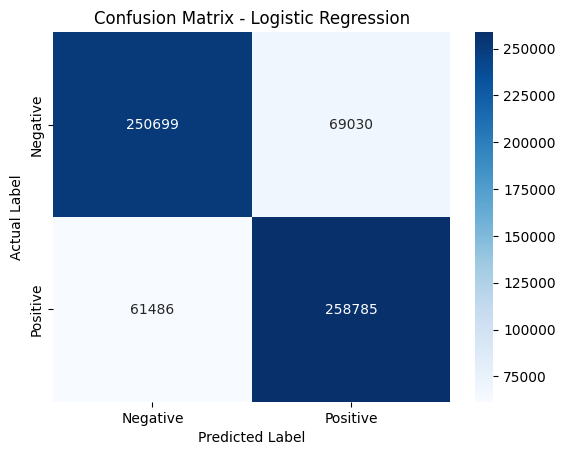

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, logreg_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

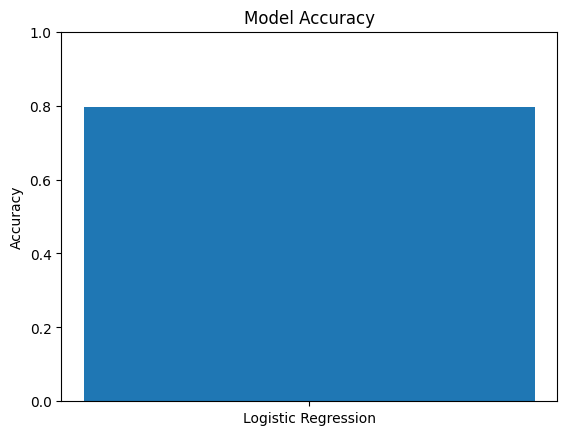

In [14]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, logreg_pred)

plt.bar(['Logistic Regression'], [accuracy])

plt.ylim(0,1)

plt.ylabel("Accuracy")
plt.title("Model Accuracy")

plt.show()

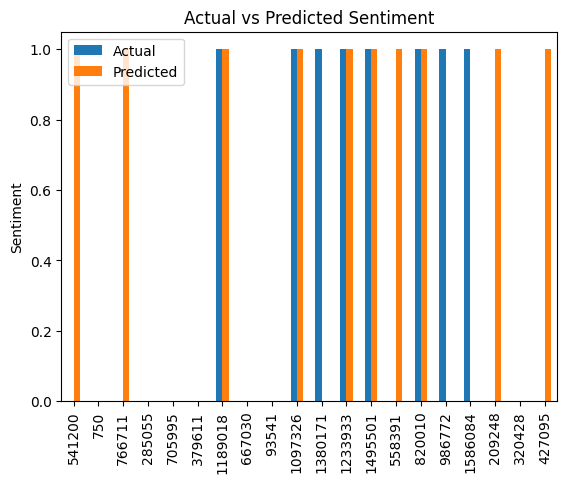

In [15]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': logreg_pred
})

comparison.head(20).plot(kind='bar')

plt.title("Actual vs Predicted Sentiment")
plt.ylabel("Sentiment")

plt.show()